
# Apple Leaf Disease: Segmentation and Classification

End-to-end deep-learning pipeline on a **cleaned, leak-free** apple-leaf dataset.

**Stage 1 - Segmentation** (lesion masks): U-Net (VGG16 encoder) and DeepLabV3+ (ResNet50 backbone).
**Stage 2 - Classification** (4 disease classes): MobileNetV2, DenseNet121, ResNet50, VGG16, InceptionV3.
**Stage 3 - Integrated inference**: disease label + lesion mask + infection severity %.

The dataset was rebuilt to remove the on-disk augmentation copies that previously leaked
rotated/flipped versions of the same leaf across train and validation. One original image is kept per
leaf. Real-field generalization is measured by 5-fold cross-validation on PlantDoc: each fold
is held out as test while the rest join training. Segmentation uses PlantVillage masks only,
with mild augmentation to preserve small lesions; classification uses stronger augmentation.

Target hardware: a single NVIDIA GPU (tested layout for an RTX 5000, 16-32 GB VRAM).
Run the cells top to bottom; each cell prints or plots its own output.



## 1. Setup

Install the requirements once (uncomment the pip line the first time), then import
everything, fix the random seed, and detect the GPU.


In [1]:
# !pip install torch torchvision segmentation-models-pytorch albumentations opencv-python-headless scikit-learn matplotlib seaborn pandas tqdm
import os, random, time, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models as tvm

import albumentations as A
import segmentation_models_pytorch as smp
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score,
                             roc_curve, auc)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
torch.backends.cudnn.benchmark = True
print("PyTorch", torch.__version__, "| device:", DEVICE,
      "|", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU only")


C:\Users\cy\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.6.0+cu124 | device: cuda | NVIDIA RTX 5000 Ada Generation



### Configuration

Point `DATA_ROOT` at the extracted `clean_apple_dataset` folder. All knobs live here.
Set `QUICK_TEST = True` for a fast 2-epoch smoke run to confirm everything works, then set it
back to `False` and re-run for the full training.


In [2]:
DATA_ROOT = Path("./village_doc_cv/village_doc_cv")     # <-- extract village_doc_cv.zip and point here
OUT = Path("./outputs"); OUT.mkdir(exist_ok=True)
for sub in ["models", "figures", "tables"]:
    (OUT / sub).mkdir(exist_ok=True)

CLASSES = ["Apple___Apple_scab", "Apple___Black_rot", "Apple___Cedar_apple_rust", "Apple___healthy"]
NICE = {c: c.replace("Apple___", "").replace("_", " ") for c in CLASSES}
NUM_CLASSES = len(CLASSES)

QUICK_TEST = False          # True = 2 epochs for a quick check; set False for full training

IMG_SIZE = 224             # default input size (InceptionV3 overrides to 299 automatically)
SEG_SIZE = 256             # segmentation input size (masks are 256x256)
BATCH = 16
SEG_EPOCHS   = 2 if QUICK_TEST else 45
CLS_PHASE1   = 1 if QUICK_TEST else 5     # frozen-backbone warm-up
CLS_PHASE2   = 2 if QUICK_TEST else 25    # fine-tuning
NUM_WORKERS  = 0 if os.name == "nt" else 4

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
print("Config ready. QUICK_TEST =", QUICK_TEST, "| batch =", BATCH, "| device =", DEVICE)

Config ready. QUICK_TEST = False | batch = 16 | device = cuda



### FLOPs helper

Small utility used later to report each model's compute cost. It uses PyTorch's built-in FLOP
counter and returns None if the counter is unavailable in the installed PyTorch version.


In [3]:
def get_flops(model, size):
    try:
        from torch.utils.flop_counter import FlopCounterMode
        model.eval(); dummy = torch.randn(1, 3, size, size, device=DEVICE)
        with torch.no_grad(), FlopCounterMode(display=False) as fc:
            model(dummy)
        return fc.get_total_flops() / 1e9
    except Exception:
        return None



## 2. Load the cleaned dataset

The cleaned dataset ships ready-made split files (`splits/train.csv`, `val.csv`, `test.csv`)
so the split is fixed and reproducible. Each row has the image path, its mask path (empty for
the few images without a mask), the class, the split, and the lesion-pixel fraction.


In [4]:
def load_split(name):
    df = pd.read_csv(DATA_ROOT / "splits" / f"{name}.csv")
    df["image_path"] = df["image_path"].apply(lambda p: str(DATA_ROOT / p))
    df["mask_path"] = df["mask_path"].apply(lambda p: str(DATA_ROOT / p) if isinstance(p, str) and p else "")
    return df

train_df, val_df, test_df = load_split("train"), load_split("val"), load_split("test")
plantdoc_all_df = load_split("plantdoc_all")
print("Split sizes -> train(PV):", len(train_df), "| val:", len(val_df),
      "| test(PV):", len(test_df), "| PlantDoc(all, for CV):", len(plantdoc_all_df))
_counts = train_df["class"].value_counts().reindex(CLASSES).fillna(0).values.astype("float32")
CLASS_WEIGHTS = torch.tensor(_counts.sum() / (len(CLASSES) * np.maximum(_counts, 1)), dtype=torch.float32)
print("Class weights:", {NICE[c]: round(float(w), 2) for c, w in zip(CLASSES, CLASS_WEIGHTS)})
print("\nClass counts per split:")
print(pd.concat({s: d["class"].map(NICE).value_counts()
                 for s, d in [("train", train_df), ("val", val_df), ("test", test_df)]}, axis=1).fillna(0).astype(int))


Split sizes -> train(PV): 2271 | val: 486 | test(PV): 490 | PlantDoc(all, for CV): 287
Class weights: {'Apple scab': 1.29, 'Black rot': 1.31, 'Cedar apple rust': 2.63, 'healthy': 0.48}

Class counts per split:
                  train  val  test
class                             
healthy            1180  253   254
Apple scab          441   94    95
Black rot           434   93    94
Cedar apple rust    216   46    47



### Confirm there is no leakage

Because the dataset was de-duplicated to one image per leaf, no image path can appear in more
than one split. This cell checks that explicitly.


In [5]:
paths = {"train": set(train_df.image_path), "val": set(val_df.image_path), "test": set(test_df.image_path)}
print("train and val overlap :", len(paths["train"] & paths["val"]))
print("train and test overlap:", len(paths["train"] & paths["test"]))
print("val and test overlap  :", len(paths["val"] & paths["test"]))
print("=> all zero means the splits are disjoint (no leakage).")


train and val overlap : 0
train and test overlap: 0
val and test overlap  : 0
=> all zero means the splits are disjoint (no leakage).



## 3. Inspect the data

Plot the class distribution and show a few sample images per class.


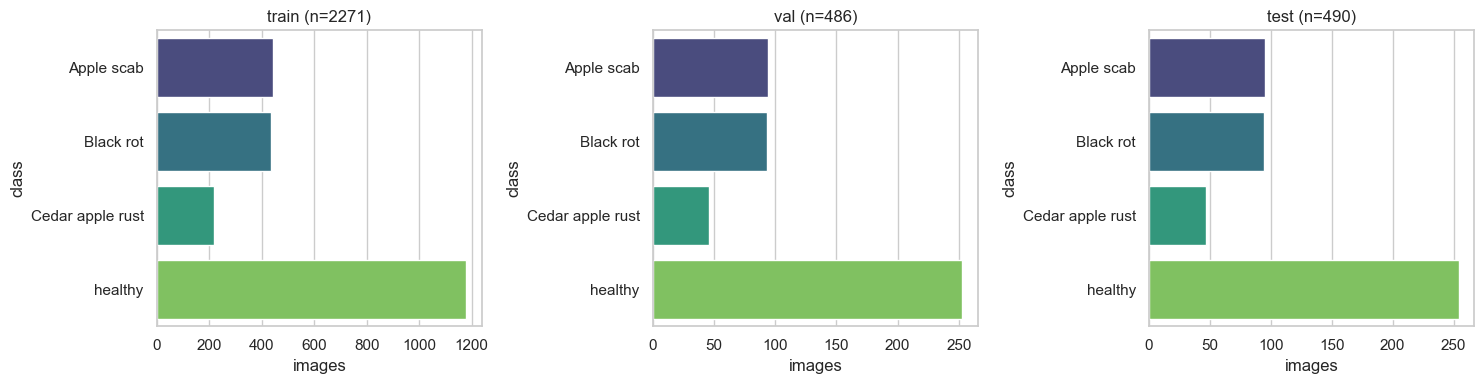

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, (s, d) in zip(ax, [("train", train_df), ("val", val_df), ("test", test_df)]):
    vc = d["class"].map(NICE).value_counts().reindex([NICE[c] for c in CLASSES])
    sns.barplot(x=vc.values, y=vc.index, hue=vc.index, palette="viridis", legend=False, ax=a)
    a.set_title(f"{s} (n={len(d)})"); a.set_xlabel("images")
plt.tight_layout(); plt.savefig(OUT / "figures/class_distribution.png", dpi=150); plt.show()


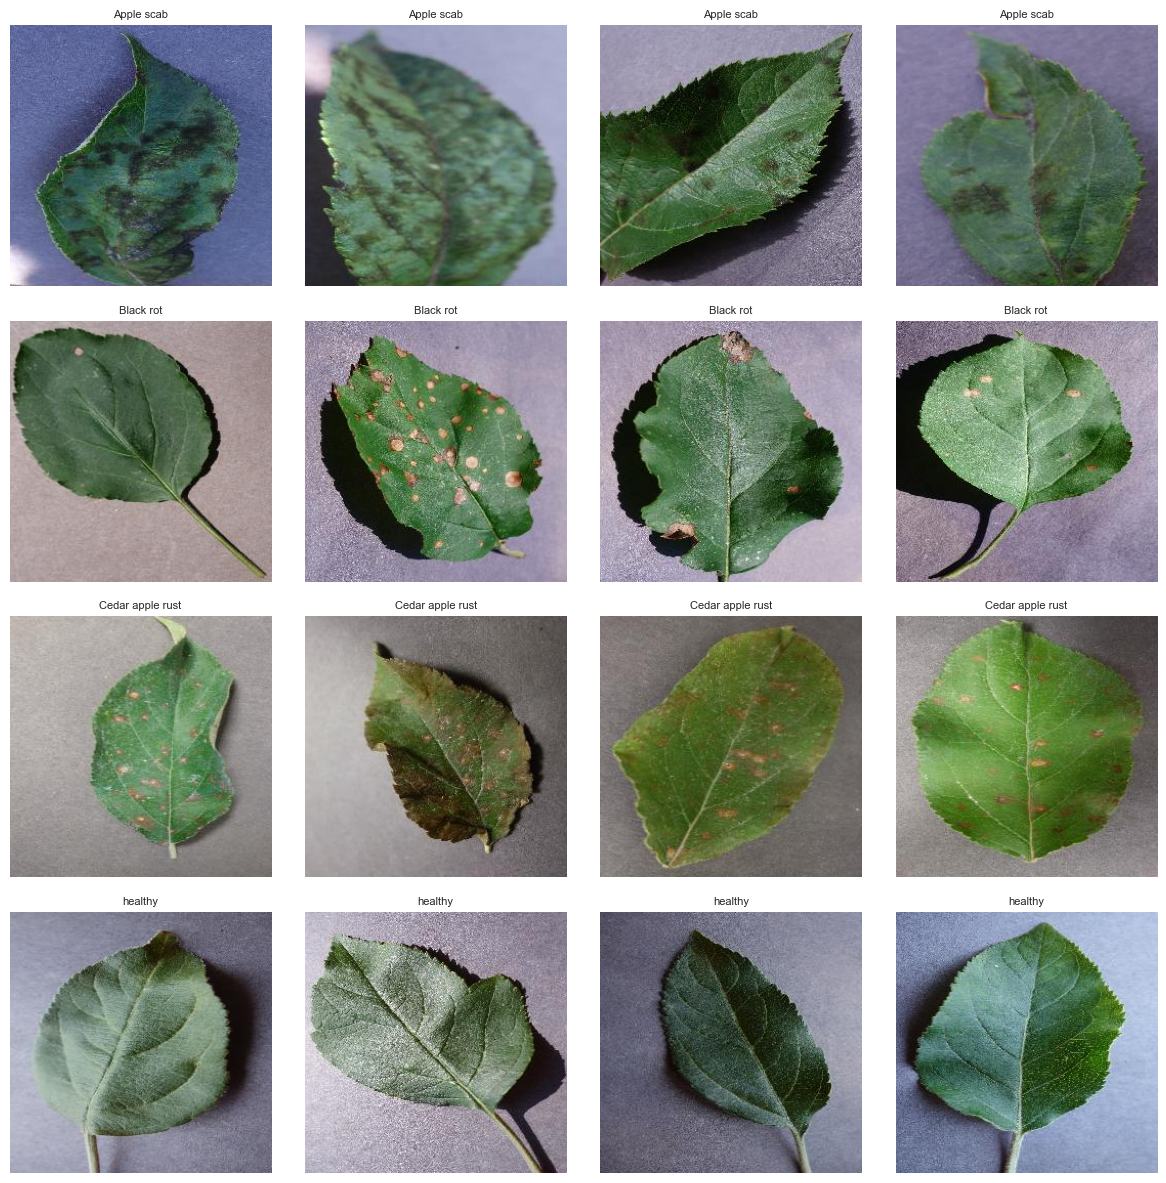

In [7]:
def denorm(x):
    x = x.transpose(1, 2, 0) * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(x, 0, 1)

fig, ax = plt.subplots(len(CLASSES), 4, figsize=(12, 3 * len(CLASSES)))
for i, c in enumerate(CLASSES):
    sub = train_df[train_df["class"] == c].sample(4, random_state=SEED)
    for j, (_, r) in enumerate(sub.iterrows()):
        img = cv2.cvtColor(cv2.imread(r.image_path), cv2.COLOR_BGR2RGB)
        ax[i, j].imshow(img); ax[i, j].axis("off")
        ax[i, j].set_title(NICE[c], fontsize=8)
plt.tight_layout(); plt.savefig(OUT / "figures/sample_images.png", dpi=150); plt.show()



## 4. Augmentation

Augmentation is applied at training time only (never baked onto disk). Validation and test use
resize + normalize only. This is what makes the before/after augmentation comparison in Stage 2
meaningful.


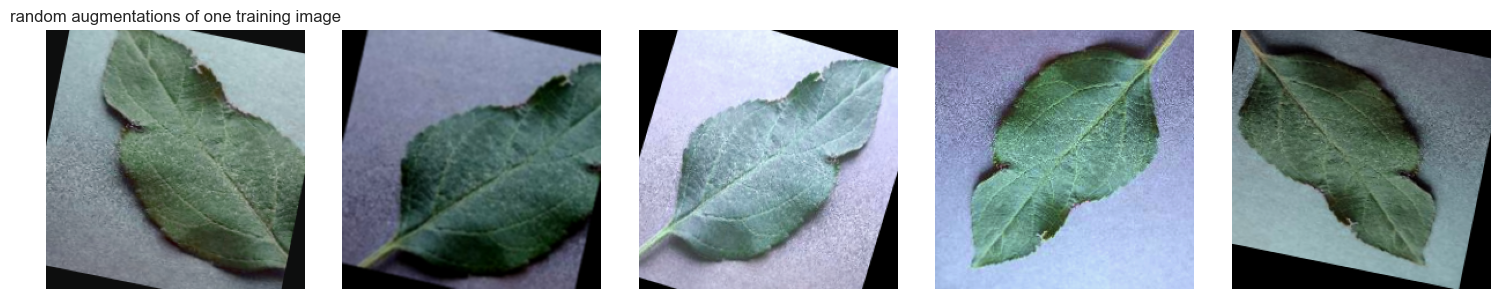

In [8]:
def seg_train_tf(size):
    # mild augmentation for segmentation - preserves small lesions
    return A.Compose([
        A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
        A.Rotate(limit=25, border_mode=cv2.BORDER_CONSTANT, p=0.5),
        A.RandomBrightnessContrast(0.2, 0.2, p=0.4),
        A.GaussianBlur((3, 5), p=0.2),
        A.Resize(size, size),
        A.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def cls_train_tf(size):
    # stronger, domain-oriented augmentation for classification generalization
    return A.Compose([
        A.RandomResizedCrop(size, size, scale=(0.6, 1.0), ratio=(0.75, 1.33), p=1.0),
        A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
        A.Rotate(limit=35, border_mode=cv2.BORDER_CONSTANT, p=0.6),
        A.RandomBrightnessContrast(0.3, 0.3, p=0.6),
        A.HueSaturationValue(20, 30, 20, p=0.5),
        A.RGBShift(20, 20, 20, p=0.3),
        A.GaussianBlur((3, 7), p=0.3),
        A.CoarseDropout(max_holes=8, max_height=size // 8, max_width=size // 8, fill_value=0, p=0.3),
        A.ShiftScaleRotate(0.08, 0.15, 20, border_mode=cv2.BORDER_CONSTANT, p=0.4),
        A.Resize(size, size),
        A.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

def eval_tf(size):
    return A.Compose([A.Resize(size, size), A.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

# quick visual of one image under several random augmentations
_r = train_df.sample(1, random_state=1).iloc[0]
_img = cv2.cvtColor(cv2.imread(_r.image_path), cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(1, 5, figsize=(15, 3))
t = cls_train_tf(IMG_SIZE)
for a in ax:
    a.imshow(denorm(t(image=_img)["image"].transpose(2, 0, 1))); a.axis("off")
ax[0].set_title("random augmentations of one training image")
plt.tight_layout(); plt.savefig(OUT / "figures/augmentation_examples.png", dpi=150); plt.show()



## 5. Note on lesion localization

The lesion masks distributed with the source release were found to be unreliable (for several
leaves the mask does not overlap the visible lesion, and a standard color detector agrees with
them at only ~0.17 IoU). This pipeline therefore does NOT perform pixel-level segmentation.
Disease regions are localized instead with Grad-CAM (Section 8), which needs no lesion masks.



## 6. Stage 2 - Classification

Five ImageNet-pretrained backbones are fine-tuned with a two-phase schedule (frozen-backbone
warm-up, then fine-tuning). Each keeps the head described in the study:

| Model | Head | Input |
|-------|------|-------|
| MobileNetV2 | GAP -> 128 -> Dropout 0.2 -> 4 | 224 |
| DenseNet121 | GAP -> 256 -> Dropout 0.2 -> 4 | 224 |
| ResNet50 | GAP -> 4 | 224 |
| VGG16 | Flatten -> 512 -> Dropout 0.5 -> 4 | 224 |
| InceptionV3 | GAP -> 256 -> Dropout 0.3 -> 4 | 299 |

InceptionV3 needs 299x299 input, so it gets its own size automatically; the other four use 224.


In [9]:
MODEL_SIZE = {"mobilenetv2": 224, "densenet121": 224, "resnet50": 224, "vgg16": 224, "inceptionv3": 299}

class ClsDS(Dataset):
    def __init__(self, df, tf):
        self.df = df; self.tf = tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = cv2.cvtColor(cv2.imread(r.image_path), cv2.COLOR_BGR2RGB)
        x = torch.from_numpy(self.tf(image=img)["image"].transpose(2, 0, 1)).float()
        return x, CLASSES.index(r["class"])

def cls_loader(df, size, train, augment=True):
    tf = (cls_train_tf(size) if augment else eval_tf(size)) if train else eval_tf(size)
    return DataLoader(ClsDS(df, tf), batch_size=BATCH, shuffle=train,
                      num_workers=NUM_WORKERS, pin_memory=USE_AMP, drop_last=train)


In [10]:
def head(in_f, hidden, drop):
    layers = [nn.Flatten()]
    if hidden:
        layers += [nn.Linear(in_f, hidden), nn.ReLU(True), nn.Dropout(drop)]
        in_f = hidden
    layers += [nn.Linear(in_f, NUM_CLASSES)]
    return nn.Sequential(*layers)

def build_cls(name, pretrained=True):
    w = "IMAGENET1K_V1" if pretrained else None
    if name == "mobilenetv2":
        m = tvm.mobilenet_v2(weights=w); feat = m.features; pool = nn.AdaptiveAvgPool2d(1)
        return nn.Sequential(feat, pool, head(1280, 128, 0.2)), feat
    if name == "densenet121":
        m = tvm.densenet121(weights=w); feat = m.features
        return nn.Sequential(feat, nn.ReLU(True), nn.AdaptiveAvgPool2d(1), head(1024, 256, 0.2)), feat
    if name == "resnet50":
        m = tvm.resnet50(weights=w); feat = nn.Sequential(*list(m.children())[:-1])
        return nn.Sequential(feat, head(2048, None, 0.0)), feat
    if name == "vgg16":
        m = tvm.vgg16(weights=w); feat = m.features; pool = nn.AdaptiveAvgPool2d((7, 7))
        return nn.Sequential(feat, pool, head(512 * 7 * 7, 512, 0.5)), feat
    if name == "inceptionv3":
        m = tvm.inception_v3(weights=w, aux_logits=True); m.aux_logits = False; m.AuxLogits = None
        feat = nn.Sequential(m.Conv2d_1a_3x3, m.Conv2d_2a_3x3, m.Conv2d_2b_3x3, m.maxpool1,
                             m.Conv2d_3b_1x1, m.Conv2d_4a_3x3, m.maxpool2,
                             m.Mixed_5b, m.Mixed_5c, m.Mixed_5d, m.Mixed_6a, m.Mixed_6b,
                             m.Mixed_6c, m.Mixed_6d, m.Mixed_6e, m.Mixed_7a, m.Mixed_7b, m.Mixed_7c)
        return nn.Sequential(feat, nn.AdaptiveAvgPool2d(1), head(2048, 256, 0.3)), feat
    raise ValueError(name)


In [11]:
@torch.no_grad()
def cls_predict(model, loader):
    model.eval(); ys, ps = [], []
    for x, y in loader:
        with torch.autocast("cuda", enabled=USE_AMP):
            out = model(x.to(DEVICE))
        ps.append(torch.softmax(out.float(), 1).cpu().numpy()); ys.append(y.numpy())
    return np.concatenate(ys), np.concatenate(ps)

def train_cls(name, df_tr, df_va, p1, p2, pretrained=True, augment=True, verbose=True, arch=None):
    arch = arch or name
    size = MODEL_SIZE[arch]
    model, feat = build_cls(arch, pretrained); model = model.to(DEVICE)
    tr = cls_loader(df_tr, size, True, augment); va = cls_loader(df_va, size, False)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP); lossf = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.to(DEVICE))
    hist = []; best = {"acc": -1.0, "sd": None, "bad": 0}; PATIENCE = 8

    def run(epochs, lr, phase):
        opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=1e-4)
        for ep in range(epochs):
            model.train(); tl = 0.0
            for x, y in tr:
                x, y = x.to(DEVICE), y.to(DEVICE)
                opt.zero_grad()
                with torch.autocast("cuda", enabled=USE_AMP):
                    loss = lossf(model(x), y)
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
                tl += float(loss)
            yt, pp = cls_predict(model, va); acc = accuracy_score(yt, pp.argmax(1))
            hist.append({"phase": phase, "epoch": ep + 1, "train_loss": tl / len(tr), "val_acc": acc})
            if verbose: print(f"[{name}] phase{phase} epoch {ep+1} val_acc={acc:.4f}")
            if acc > best["acc"]:
                best["acc"] = acc; best["sd"] = {k: v.cpu().clone() for k, v in model.state_dict().items()}; best["bad"] = 0
            elif phase == 2:
                best["bad"] += 1
                if best["bad"] >= PATIENCE:
                    if verbose: print(f"[{name}] early stopping at phase 2 epoch {ep+1}")
                    return

    for p in feat.parameters(): p.requires_grad = False       # phase 1: frozen backbone
    run(p1, 1e-3, 1)
    for p in feat.parameters(): p.requires_grad = True         # phase 2: fine-tune
    run(p2, 1e-4, 2)
    if best["sd"] is not None: model.load_state_dict(best["sd"])   # restore best checkpoint
    torch.save(model.state_dict(), OUT / f"models/cls_{name}.pt")
    return model, pd.DataFrame(hist)

In [12]:
CLS_MODELS, CLS_HIST = {}, {}
for _n in ["mobilenetv2", "densenet121", "resnet50", "vgg16", "inceptionv3"]:
    print("=== training", _n, "===")
    CLS_MODELS[_n], CLS_HIST[_n] = train_cls(_n, train_df, val_df, CLS_PHASE1, CLS_PHASE2)


=== training mobilenetv2 ===


[mobilenetv2] phase1 epoch 1 val_acc=0.9136


[mobilenetv2] phase1 epoch 2 val_acc=0.9856


[mobilenetv2] phase1 epoch 3 val_acc=0.9486


[mobilenetv2] phase1 epoch 4 val_acc=0.9774


...

[inceptionv3] phase2 epoch 7 val_acc=0.9979


[inceptionv3] phase2 epoch 8 val_acc=1.0000


[inceptionv3] phase2 epoch 9 val_acc=1.0000


[inceptionv3] phase2 epoch 10 val_acc=0.9938


[inceptionv3] phase2 epoch 11 val_acc=0.9979
[inceptionv3] early stopping at phase 2 epoch 11


In [13]:
# evaluate all five on the test set
def eval_cls(model, name):
    yt, pp = cls_predict(model, cls_loader(test_df, MODEL_SIZE[name], False))
    yp = pp.argmax(1)
    n_params = sum(p.numel() for p in model.parameters())
    model.eval(); size = MODEL_SIZE[name]; dummy = torch.randn(1, 3, size, size, device=DEVICE)
    with torch.no_grad():
        for _ in range(3): model(dummy)
        if USE_AMP: torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(20): model(dummy)
        if USE_AMP: torch.cuda.synchronize()
        infer_ms = (time.time() - t0) / 20 * 1000
    flops = get_flops(model, size)
    return {"model": name,
            "accuracy": accuracy_score(yt, yp),
            "precision": precision_score(yt, yp, average="macro", zero_division=0),
            "recall": recall_score(yt, yp, average="macro", zero_division=0),
            "f1": f1_score(yt, yp, average="macro", zero_division=0),
            "roc_auc": roc_auc_score(yt, pp, multi_class="ovr", average="macro"),
            "params_M": round(n_params / 1e6, 2), "infer_ms": round(infer_ms, 2),
            "flops_G": round(flops, 2) if flops else None}, yt, pp

cls_rows = {}; cls_pred = {}
for n, m in CLS_MODELS.items():
    row, yt, pp = eval_cls(m, n); cls_rows[n] = row; cls_pred[n] = (yt, pp)
cls_table = pd.DataFrame(cls_rows.values())[["model", "accuracy", "precision", "recall", "f1", "roc_auc", "params_M", "infer_ms", "flops_G"]].round(4)
cls_table.to_csv(OUT / "tables/classification_results.csv", index=False)
BEST_CLS = cls_table.sort_values("accuracy", ascending=False).iloc[0]["model"]
print("Best classification model:", BEST_CLS)
cls_table.sort_values("accuracy", ascending=False)


Best classification model: densenet121


,model,accuracy,precision,recall,f1,roc_auc,params_M,infer_ms,flops_G
1,densenet121,1.0000,1.0000,1.0000,1.0000,1.0,7.22,10.78,5.67
3,vgg16,0.9980,0.9974,0.9990,0.9982,1.0,27.56,0.80,30.72
0,mobilenetv2,0.9959,0.9948,0.9980,0.9964,1.0,2.39,3.40,0.60
2,resnet50,0.9959,0.9964,0.9964,0.9964,1.0,23.52,3.64,8.17
4,inceptionv3,0.9918,0.9898,0.9928,0.9911,1.0,22.31,7.64,11.42


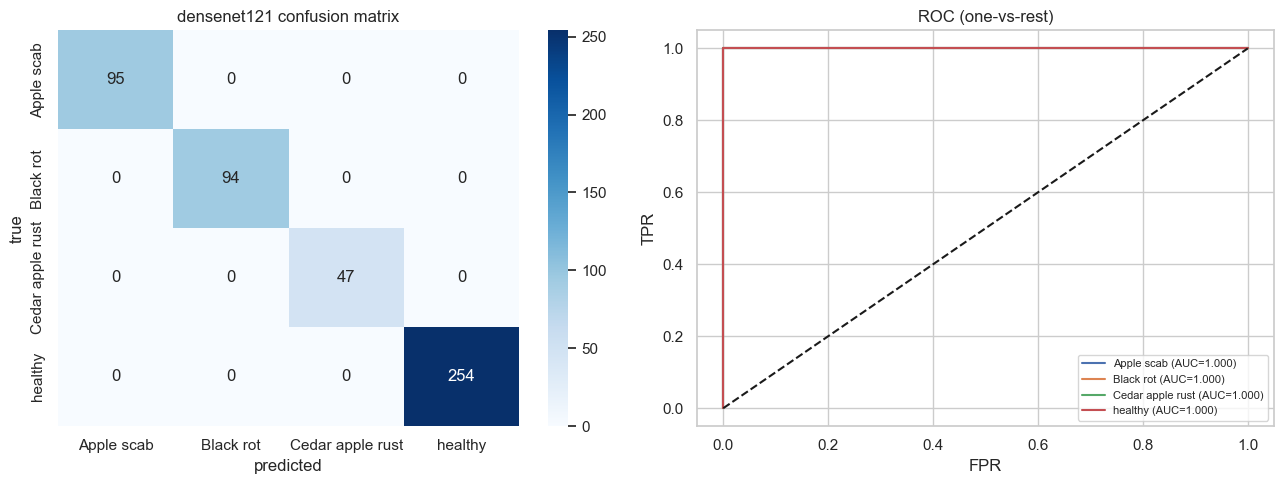

In [14]:
# confusion matrix of the best model
yt, pp = cls_pred[BEST_CLS]; cm = confusion_matrix(yt, pp.argmax(1))
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0],
            xticklabels=[NICE[c] for c in CLASSES], yticklabels=[NICE[c] for c in CLASSES])
ax[0].set_title(f"{BEST_CLS} confusion matrix"); ax[0].set_xlabel("predicted"); ax[0].set_ylabel("true")
for i, c in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve((yt == i).astype(int), pp[:, i])
    ax[1].plot(fpr, tpr, label=f"{NICE[c]} (AUC={auc(fpr, tpr):.3f})")
ax[1].plot([0, 1], [0, 1], "k--"); ax[1].set_title("ROC (one-vs-rest)")
ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT / "figures/cls_confusion_roc.png", dpi=150); plt.show()



### Before vs after augmentation (honest comparison)

This is the comparison you were unsure about. On the cleaned, leak-free split we train the same
model twice - once with augmentation off and once on - and compare test accuracy. Because no
rotated copy of a training leaf sits in the test set anymore, this gap is real.


In [15]:
aug_model = BEST_CLS
m_off, _ = train_cls(aug_model, train_df, val_df, CLS_PHASE1, CLS_PHASE2, augment=False, verbose=False)
yt_off, pp_off = cls_predict(m_off, cls_loader(test_df, MODEL_SIZE[aug_model], False))
acc_off = accuracy_score(yt_off, pp_off.argmax(1))
acc_on = cls_rows[aug_model]["accuracy"]
print(f"{aug_model}: test accuracy WITHOUT augmentation = {acc_off*100:.2f}%")
print(f"{aug_model}: test accuracy WITH augmentation    = {acc_on*100:.2f}%")
print(f"honest gain from augmentation = {(acc_on-acc_off)*100:+.2f} points")
pd.DataFrame([{"setting": "no augmentation", "test_acc": round(acc_off, 4)},
              {"setting": "with augmentation", "test_acc": round(acc_on, 4)}]).to_csv(
    OUT / "tables/augmentation_effect.csv", index=False)


densenet121: test accuracy WITHOUT augmentation = 99.59%
densenet121: test accuracy WITH augmentation    = 100.00%
honest gain from augmentation = +0.41 points


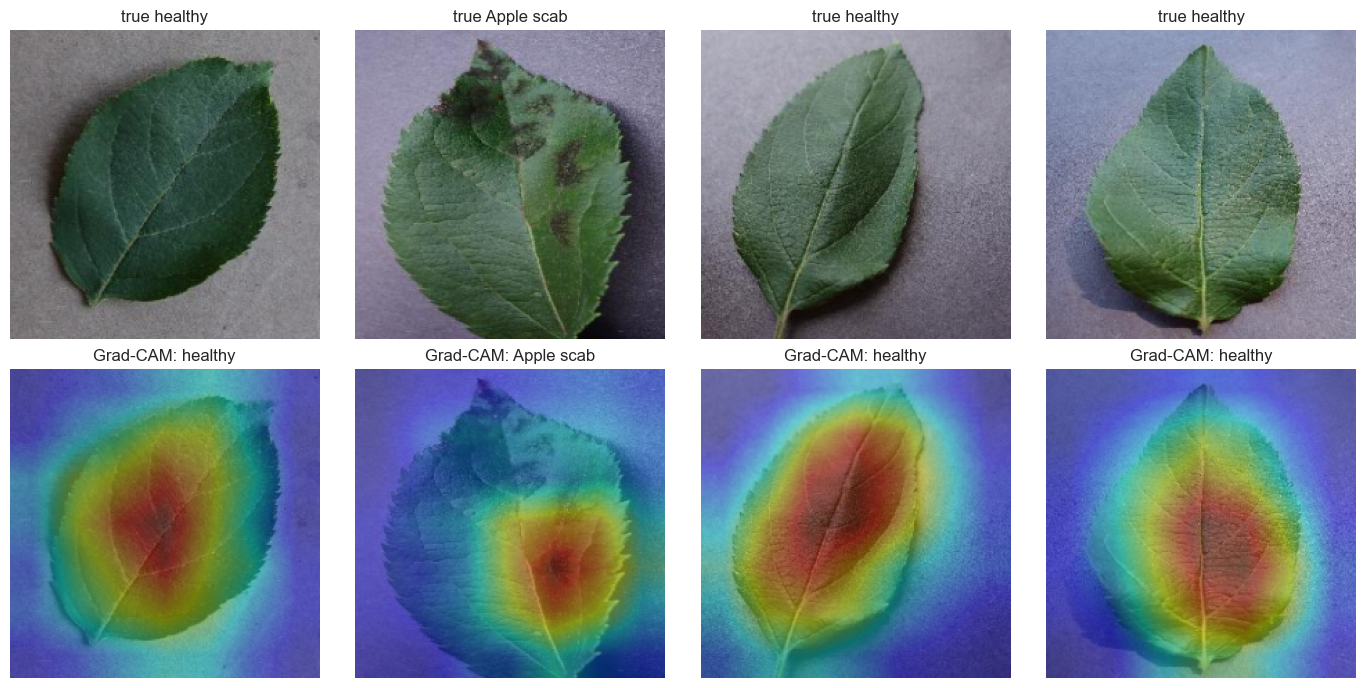

In [16]:
# Grad-CAM for the best classifier (manual hooks, no extra dependency)
def gradcam(model, feat_module, x, cls_idx=None):
    acts, grads = {}, {}
    target = [m for m in feat_module.modules() if isinstance(m, nn.Conv2d)][-1]  # last conv layer
    h1 = target.register_forward_hook(lambda m, i, o: acts.__setitem__("v", o))
    h2 = target.register_full_backward_hook(lambda m, gi, go: grads.__setitem__("v", go[0]))
    model.eval(); out = model(x)
    idx = int(out.argmax(1).item()) if cls_idx is None else int(cls_idx)
    model.zero_grad(); out[0, idx].backward()
    a = acts["v"].detach()[0]; g = grads["v"].detach()[0].mean((1, 2))
    cam = torch.relu((a * g[:, None, None]).sum(0)); cam = cam / (cam.max() + 1e-6)
    h1.remove(); h2.remove(); return cam.cpu().numpy(), idx

mdl, feat = build_cls(BEST_CLS); mdl.load_state_dict(torch.load(OUT / f"models/cls_{BEST_CLS}.pt")); mdl.to(DEVICE)
size = MODEL_SIZE[BEST_CLS]; tf = eval_tf(size)
ss = test_df.sample(4, random_state=SEED)
fig, ax = plt.subplots(2, 4, figsize=(14, 7))
for j, (_, r) in enumerate(ss.iterrows()):
    img = cv2.cvtColor(cv2.imread(r.image_path), cv2.COLOR_BGR2RGB)
    x = torch.from_numpy(tf(image=img)["image"].transpose(2, 0, 1)).float()[None].to(DEVICE)
    cam, idx = gradcam(mdl, feat, x)
    cam = cv2.resize(cam, (size, size)); base = cv2.resize(img, (size, size))
    heat = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)[:, :, ::-1]
    ov = np.uint8(0.6 * base + 0.4 * heat)
    ax[0, j].imshow(base); ax[0, j].set_title(f"true {NICE[r['class']]}"); ax[0, j].axis("off")
    ax[1, j].imshow(ov); ax[1, j].set_title(f"Grad-CAM: {NICE[CLASSES[idx]]}"); ax[1, j].axis("off")
plt.tight_layout(); plt.savefig(OUT / "figures/gradcam.png", dpi=150); plt.show()


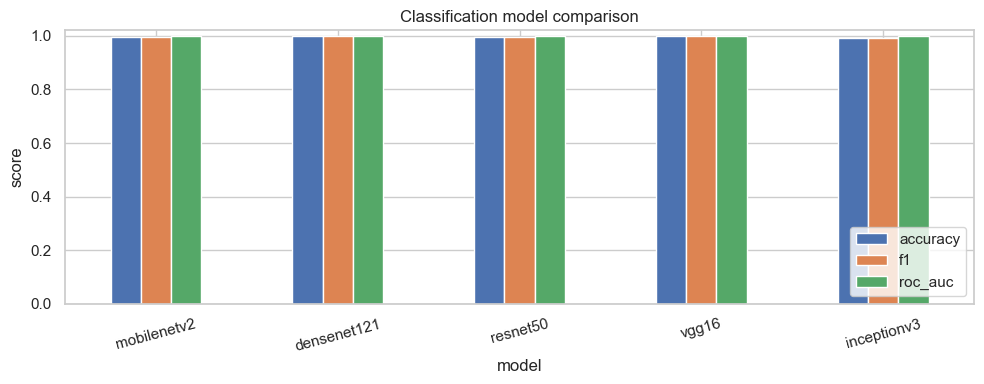

In [17]:
# five-model comparison bar chart
mt = cls_table.set_index("model")[["accuracy", "f1", "roc_auc"]]
mt.plot(kind="bar", figsize=(10, 4)); plt.title("Classification model comparison")
plt.ylim(0, 1.02); plt.ylabel("score"); plt.xticks(rotation=15); plt.legend(loc="lower right")
plt.tight_layout(); plt.savefig(OUT / "figures/cls_comparison.png", dpi=150); plt.show()



### Classification training curves and per-model diagnostics

Validation-accuracy and training-loss curves for all five models, a confusion matrix for each
model, and a per-class F1 table.


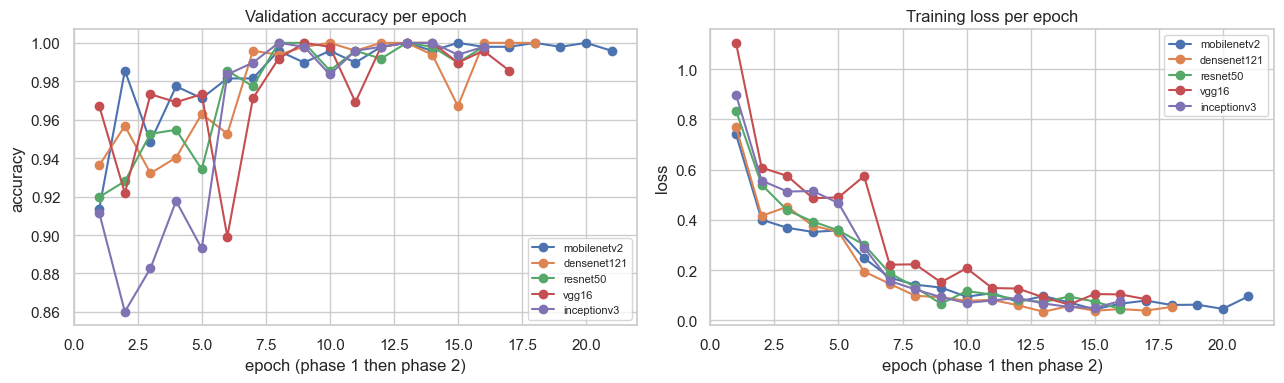

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for n, h in CLS_HIST.items():
    ax[0].plot(range(1, len(h) + 1), h["val_acc"], marker="o", label=n)
    ax[1].plot(range(1, len(h) + 1), h["train_loss"], marker="o", label=n)
ax[0].set_title("Validation accuracy per epoch"); ax[0].set_ylabel("accuracy")
ax[1].set_title("Training loss per epoch"); ax[1].set_ylabel("loss")
for a in ax: a.set_xlabel("epoch (phase 1 then phase 2)"); a.legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT / "figures/cls_curves.png", dpi=150); plt.show()


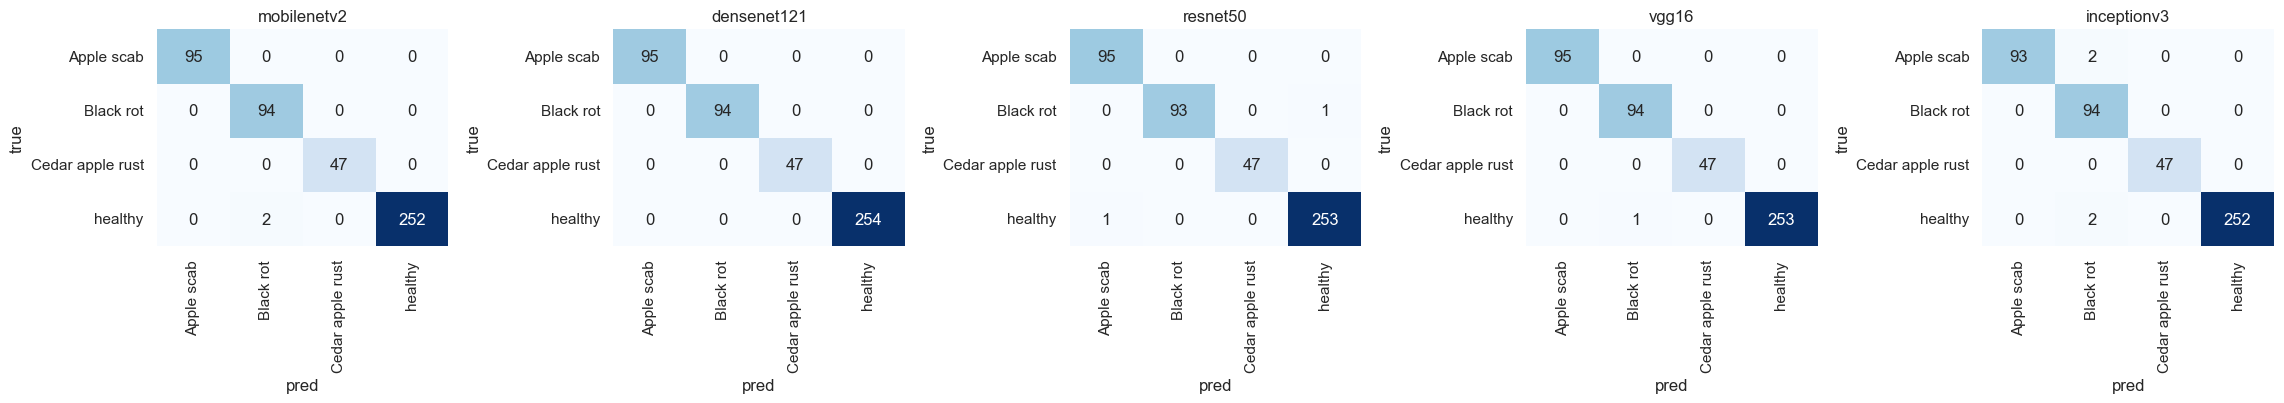

,model,Apple scab F1,Black rot F1,Cedar apple rust F1,healthy F1
0,mobilenetv2,1.000,0.989,1.0,0.996
1,densenet121,1.000,1.000,1.0,1.000
2,resnet50,0.995,0.995,1.0,0.996
3,vgg16,1.000,0.995,1.0,0.998
4,inceptionv3,0.989,0.979,1.0,0.996


In [19]:
fig, ax = plt.subplots(1, 5, figsize=(23, 4.2))
for a, (n, (yt, pp)) in zip(ax, cls_pred.items()):
    cm = confusion_matrix(yt, pp.argmax(1))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=a,
                xticklabels=[NICE[c] for c in CLASSES], yticklabels=[NICE[c] for c in CLASSES])
    a.set_title(n); a.set_xlabel("pred"); a.set_ylabel("true")
plt.tight_layout(); plt.savefig(OUT / "figures/cls_confusion_all.png", dpi=150); plt.show()

rows = []
for n, (yt, pp) in cls_pred.items():
    rep = classification_report(yt, pp.argmax(1), target_names=[NICE[c] for c in CLASSES],
                                output_dict=True, zero_division=0)
    row = {"model": n}
    for c in CLASSES:
        row[NICE[c] + " F1"] = round(rep[NICE[c]]["f1-score"], 3)
    rows.append(row)
per_class = pd.DataFrame(rows); per_class.to_csv(OUT / "tables/classification_per_class_f1.csv", index=False)
per_class



## 7. Real-field generalization: zero-shot vs 5-fold cross-validation

Two numbers on the real-field PlantDoc images (3 of the 4 classes, no Black Rot):

- **Zero-shot**: the PlantVillage-only model applied directly to all PlantDoc images.
- **5-fold CV**: PlantDoc is split into 5 folds; each fold is held out as test while the other
  four join PlantVillage in training. Every PlantDoc image is tested exactly once, so the mean
  +/- std over folds is a credible estimate from this small set.


In [20]:
from sklearn.model_selection import StratifiedKFold

# zero-shot: the PlantVillage-only best model applied to all PlantDoc
yt, pp = cls_predict(CLS_MODELS[BEST_CLS], cls_loader(plantdoc_all_df, MODEL_SIZE[BEST_CLS], False))
zero_shot = accuracy_score(yt, pp.argmax(1))
print(f"Zero-shot ({BEST_CLS} trained on PlantVillage only) on all PlantDoc: {zero_shot*100:.2f}%")

# 5-fold CV: PlantDoc folds mixed into training, each fold tested once
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y = plantdoc_all_df["class"].map(CLASSES.index).values
fold_acc, cv_yt, cv_pp = [], [], []
for k, (tr_idx, te_idx) in enumerate(skf.split(plantdoc_all_df, y)):
    pd_tr, pd_te = plantdoc_all_df.iloc[tr_idx], plantdoc_all_df.iloc[te_idx]
    mixed = pd.concat([train_df, pd_tr], ignore_index=True)
    m, _ = train_cls(f"{BEST_CLS}_cvfold{k}", mixed, val_df, CLS_PHASE1, CLS_PHASE2, verbose=False, arch=BEST_CLS)
    ytk, ppk = cls_predict(m, cls_loader(pd_te, MODEL_SIZE[BEST_CLS], False))
    a = accuracy_score(ytk, ppk.argmax(1)); fold_acc.append(a)
    cv_yt.append(ytk); cv_pp.append(ppk)
    print(f"fold {k+1}/5: PlantDoc test acc = {a*100:.1f}%  (n={len(pd_te)})")

yt, pp = np.concatenate(cv_yt), np.concatenate(cv_pp)   # each PlantDoc image tested exactly once
present = sorted(np.unique(yt).tolist())
mean, std = float(np.mean(fold_acc)), float(np.std(fold_acc))
print(f"\nZero-shot: {zero_shot*100:.2f}%   ->   5-fold CV (PlantDoc mixed in training): "
      f"{mean*100:.2f}% +/- {std*100:.2f}%")
print(classification_report(yt, pp.argmax(1), labels=present,
                            target_names=[NICE[CLASSES[i]] for i in present], zero_division=0))
pd.DataFrame([{"metric": "zero_shot_plantdoc", "value": round(zero_shot, 4)},
              {"metric": "cv_mean_plantdoc", "value": round(mean, 4)},
              {"metric": "cv_std_plantdoc", "value": round(std, 4)}]).to_csv(
    OUT / "tables/generalization_cv.csv", index=False)

Zero-shot (densenet121 trained on PlantVillage only) on all PlantDoc: 42.16%


fold 1/5: PlantDoc test acc = 86.2%  (n=58)


fold 2/5: PlantDoc test acc = 82.8%  (n=58)


fold 3/5: PlantDoc test acc = 84.2%  (n=57)


fold 4/5: PlantDoc test acc = 89.5%  (n=57)


fold 5/5: PlantDoc test acc = 78.9%  (n=57)

Zero-shot: 42.16%   ->   5-fold CV (PlantDoc mixed in training): 84.32% +/- 3.51%
                  precision    recall  f1-score   support

      Apple scab       0.87      0.65      0.74        93
Cedar apple rust       0.79      0.94      0.86       106
         healthy       0.92      0.93      0.93        88

       micro avg       0.85      0.84      0.85       287
       macro avg       0.86      0.84      0.84       287
    weighted avg       0.86      0.84      0.84       287



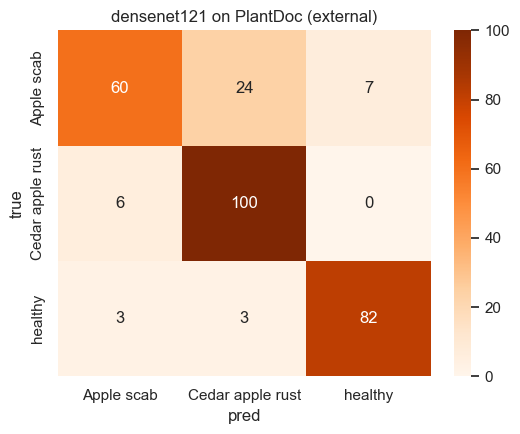

In [21]:
cm_pd = confusion_matrix(yt, pp.argmax(1), labels=present)
fig, a = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm_pd, annot=True, fmt="d", cmap="Oranges",
            xticklabels=[NICE[CLASSES[i]] for i in present], yticklabels=[NICE[CLASSES[i]] for i in present])
a.set_title(f"{BEST_CLS} on PlantDoc (external)"); a.set_xlabel("pred"); a.set_ylabel("true")
plt.tight_layout(); plt.savefig(OUT / "figures/plantdoc_confusion.png", dpi=150); plt.show()



## 8. Weakly-supervised lesion localization (Grad-CAM)

Grad-CAM on the best classifier highlights the leaf regions used for the prediction, with no
lesion mask. Besides the qualitative overlays (Section 6), we report a simple quantitative
localization score: the fraction of the activation energy that falls inside the leaf region.


In [22]:
def leaf_mask(rgb):
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV); S, V = hsv[..., 1], hsv[..., 2]
    m = ((S > 25) & (V > 20) & (V < 250)).astype(np.uint8)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
    return cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8)).astype(bool)

_m, _f = build_cls(BEST_CLS)
_m.load_state_dict(torch.load(OUT / f"models/cls_{BEST_CLS}.pt")); _m.to(DEVICE)
_size = MODEL_SIZE[BEST_CLS]; _tf = eval_tf(_size)
ratios = []
for _, r in test_df.sample(min(120, len(test_df)), random_state=SEED).iterrows():
    img = cv2.cvtColor(cv2.imread(r.image_path), cv2.COLOR_BGR2RGB)
    x = torch.from_numpy(_tf(image=img)["image"].transpose(2, 0, 1)).float()[None].to(DEVICE)
    cam, _ = gradcam(_m, _f, x)
    cam = cv2.resize(cam, (_size, _size)); lf = leaf_mask(cv2.resize(img, (_size, _size)))
    ratios.append(float((cam * lf).sum() / (cam.sum() + 1e-6)))
print(f"Grad-CAM energy inside the leaf: {100*np.mean(ratios):.1f}% +/- {100*np.std(ratios):.1f}% (n={len(ratios)})")
pd.DataFrame([{"metric": "cam_energy_inside_leaf", "mean": round(float(np.mean(ratios)), 4),
               "std": round(float(np.std(ratios)), 4)}]).to_csv(OUT / "tables/localization.csv", index=False)


Grad-CAM energy inside the leaf: 87.9% +/- 15.8% (n=120)



## 9. Summary

- Classification results, the generalization table, and the localization score are saved under
  outputs/tables/; figures under outputs/figures/; trained weights under outputs/models/.
- The central results are the in-domain accuracy, the zero-shot vs 5-fold cross-validation
  generalization on PlantDoc, and the Grad-CAM localization.

Set QUICK_TEST = False at the top and run all cells again for the full run.


In [23]:
from matplotlib.backends.backend_pdf import PdfPages

def _tbl_page(pdf, title, df):
    fig, ax = plt.subplots(figsize=(11, 0.5 * len(df) + 2)); ax.axis("off")
    ax.set_title(title, fontweight="bold", pad=20)
    tb = ax.table(cellText=df.astype(object).values, colLabels=df.columns, loc="center", cellLoc="center")
    tb.auto_set_font_size(False); tb.set_fontsize(8); tb.scale(1, 1.4)
    pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

def _img_page(pdf, title, path):
    if not Path(path).exists(): return
    fig, ax = plt.subplots(figsize=(11, 8)); ax.axis("off"); ax.set_title(title)
    ax.imshow(plt.imread(str(path))); pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

with PdfPages(OUT / "report.pdf") as pdf:
    fig = plt.figure(figsize=(11, 8))
    fig.text(0.5, 0.6, "Apple Leaf Disease\nClassification and Weakly-Supervised Localization",
             ha="center", fontsize=20, fontweight="bold")
    fig.text(0.5, 0.42, f"Best classification model: {BEST_CLS}", ha="center", fontsize=13)
    pdf.savefig(fig); plt.close(fig)
    _tbl_page(pdf, "Classification results", cls_table)
    _tbl_page(pdf, "Per-class F1", per_class)
    for t, f in [("Class distribution", "figures/class_distribution.png"),
                 ("Sample images", "figures/sample_images.png"),
                 ("Classification training curves", "figures/cls_curves.png"),
                 ("Confusion matrices (all models)", "figures/cls_confusion_all.png"),
                 ("Best model confusion + ROC", "figures/cls_confusion_roc.png"),
                 ("Model comparison", "figures/cls_comparison.png"),
                 ("Grad-CAM localization", "figures/gradcam.png"),
                 ("PlantDoc CV confusion", "figures/plantdoc_confusion.png")]:
        _img_page(pdf, t, OUT / f)
print("PDF report saved to", OUT / "report.pdf")


PDF report saved to outputs\report.pdf


In [24]:
print("Classification (in-domain) results:")
print(cls_table.sort_values("accuracy", ascending=False).to_string(index=False))
print("\nBest classification model:", BEST_CLS)
print("All tables/figures/models saved under:", OUT.resolve())


Classification (in-domain) results:
      model  accuracy  precision  recall     f1  roc_auc  params_M  infer_ms  flops_G
densenet121    1.0000     1.0000  1.0000 1.0000      1.0      7.22     10.78     5.67
      vgg16    0.9980     0.9974  0.9990 0.9982      1.0     27.56      0.80    30.72
mobilenetv2    0.9959     0.9948  0.9980 0.9964      1.0      2.39      3.40     0.60
   resnet50    0.9959     0.9964  0.9964 0.9964      1.0     23.52      3.64     8.17
inceptionv3    0.9918     0.9898  0.9928 0.9911      1.0     22.31      7.64    11.42

Best classification model: densenet121
All tables/figures/models saved under: D:\ADDC new\final paper\outputs
